<a href="https://colab.research.google.com/github/Roshni-AngelAlex/DEEP-LEARNING/blob/main/24BAD101_DL_LAB_EX_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DEEP LEARNING (24ADI006)

# LAB EXP NO: 3
Implementation of CNN for Image Classification


NAME : ROSHNI ANGEL A

ROLL NO : 24BAD101

DEPARTMENT : AI/DS

**Task A: Dataset Preparation**

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split



# Load CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Normalize pixel values to [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train_full = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test, 10)

# Split into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42)

print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1877s 11us/step
Train: (40000, 32, 32, 3) Val: (10000, 32, 32, 3) Test: (10000, 32, 32, 3)


**Task B: CNN Model Implementation**

In [2]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')   # Softmax output layer
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

**Task C: Model Training and Evaluation**

In [3]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64
)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Testing Accuracy:", test_acc)
print("Testing Loss:", test_loss)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 162ms/step - accuracy: 0.3655 - loss: 1.7267 - val_accuracy: 0.5295 - val_loss: 1.3399
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.5092 - loss: 1.3637 - val_accuracy: 0.5767 - val_loss: 1.1879
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 151ms/step - accuracy: 0.5813 - loss: 1.1878 - val_accuracy: 0.6461 - val_loss: 1.0108
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 151ms/step - accuracy: 0.6245 - loss: 1.0735 - val_accuracy: 0.6643 - val_loss: 0.9655
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 151ms/step - accuracy: 0.6553 - loss: 0.9871 - val_accuracy: 0.7003 - val_loss: 0.8723
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 160ms/step - accuracy: 0.6816 - loss: 0.9120 - val_accuracy: 0.6988 - val_loss: 0.8726
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.7023 - loss: 0.8521 - val_accuracy: 0.7142 - val_loss: 0.8105
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.7210 - loss

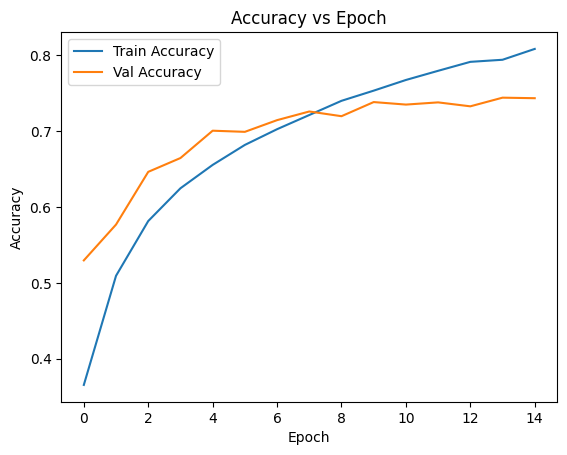

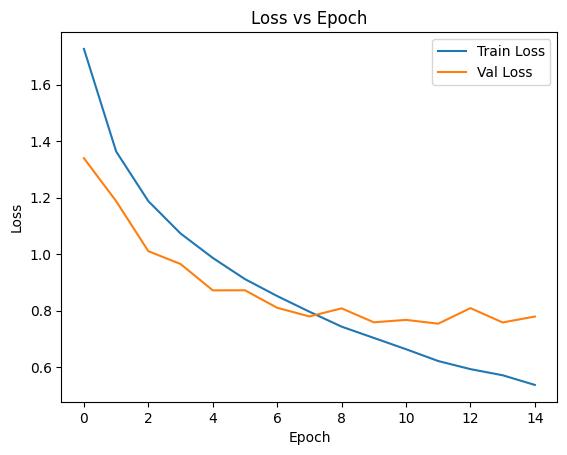

In [4]:
import matplotlib.pyplot as plt

# Accuracy vs Epoch
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.title('Accuracy vs Epoch')
plt.show()

# Loss vs Epoch
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('Loss vs Epoch')
plt.show()

**Task D: Performance Analysis**

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


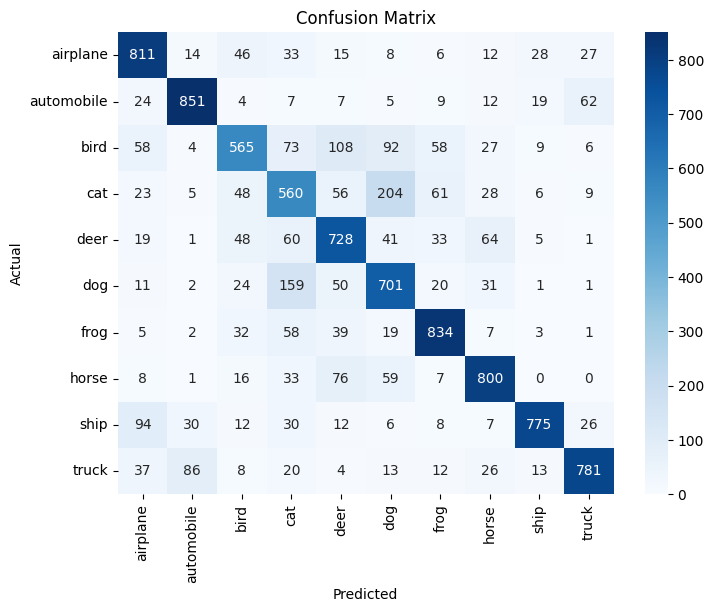

              precision    recall  f1-score   support

    airplane       0.74      0.81      0.78      1000
  automobile       0.85      0.85      0.85      1000
        bird       0.70      0.56      0.63      1000
         cat       0.54      0.56      0.55      1000
        deer       0.66      0.73      0.69      1000
         dog       0.61      0.70      0.65      1000
        frog       0.80      0.83      0.81      1000
       horse       0.79      0.80      0.79      1000
        ship       0.90      0.78      0.83      1000
       truck       0.85      0.78      0.82      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



In [5]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_names))

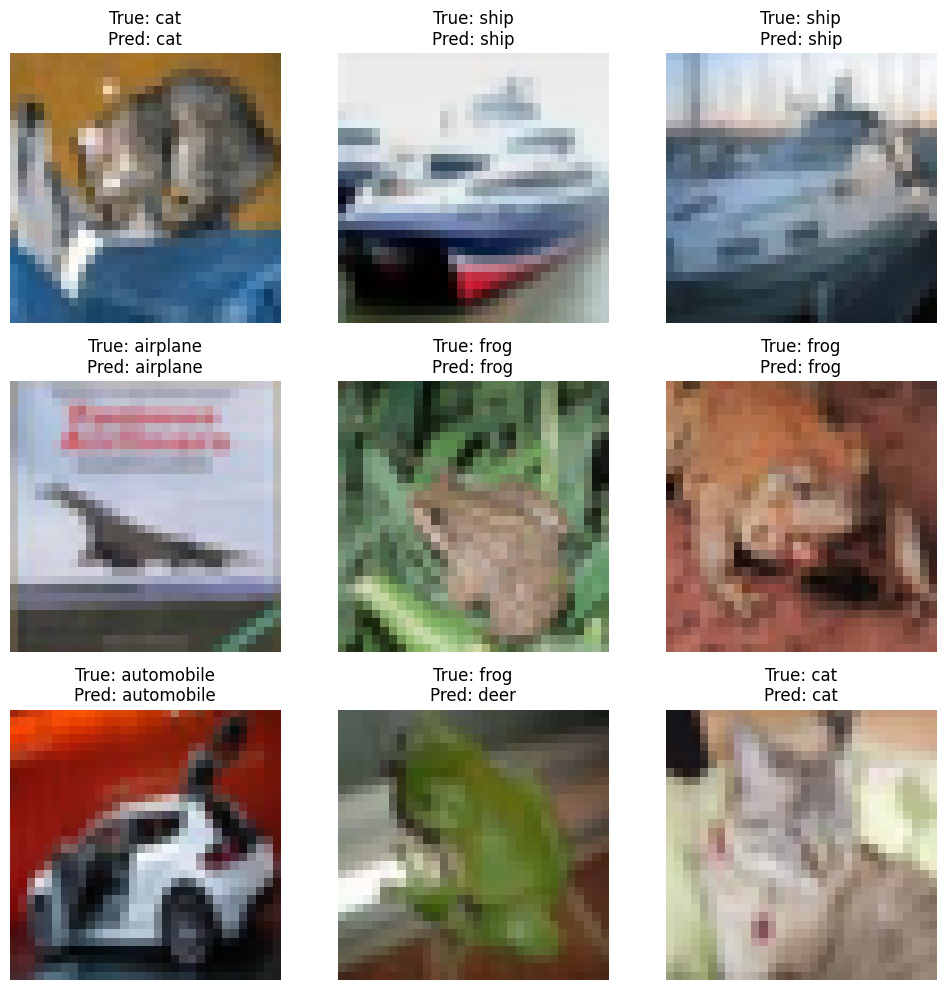

In [6]:
# Sample predictions
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i])
    plt.title(f"True: {class_names[y_true[i]]}\nPred: {class_names[y_pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

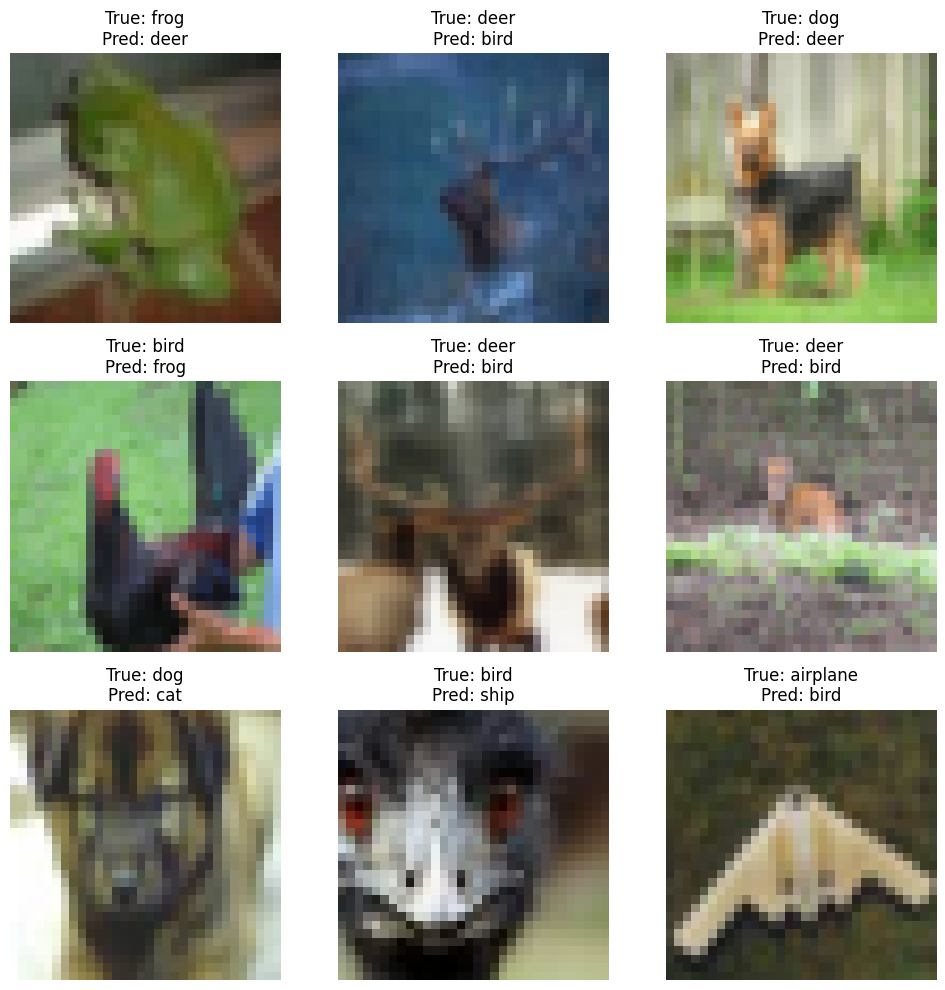

In [7]:
# Misclassified images
mis_idx = np.where(y_pred_classes != y_true)[0]
plt.figure(figsize=(10,10))
for i, idx in enumerate(mis_idx[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_classes[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Discussion — Strengths and Limitations of CNNs

**Strengths:** CNNs automatically learn hierarchical spatial features without manual feature engineering, share weights via convolution filters (fewer parameters than fully connected networks), are translation-invariant due to pooling, and achieve high accuracy on complex visual recognition tasks such as CIFAR-10 classification.

**Limitations:** CNNs require large labeled datasets and significant computational resources (GPU) to train well, can overfit on small datasets, are sensitive to hyperparameter choices (learning rate, filter sizes, depth), and can be fooled by adversarial perturbations. They also offer limited interpretability of learned features compared to simpler models.